# Sector Rotation Early Warning System


In [194]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from urllib.parse import quote
from datetime import date
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 140,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BASE_URL = 'https://api.massive.com'
API_KEY  = '7gjThzOOPPal8jKWBbDl8lgp6ZM1DSYh'

DEFENSIVE   = ['XLP', 'XLV', 'XLU']
HIGH_BETA   = ['XLK', 'XLY']
BENCHMARK   = 'SPY'
ALL_TICKERS = DEFENSIVE + HIGH_BETA + [BENCHMARK]

START       = '2021-01-01'
END         = str(date.today())

MOM_WINDOW    = 20    # days for momentum (used in per-sector chart)
ZSCORE_WINDOW = 252   # rolling lookback window
MA_WINDOW     = 50    # SPX moving average window
FWD_WINDOW    = 20    # forward look-ahead for drawdown labelling
DD_THRESH     = -0.05 # -5% → counts as a drawdown

WARN_PCT    = 95      # warning threshold percentile
EXTREME_PCT = 99      # extreme threshold percentile

print(f'Config loaded. Fetching up to {END}.')

Config loaded. Fetching up to 2026-09-06.


In [195]:
# Fetch Data

def fetch_ticker(ticker, from_date, to_date):
    ticker_encoded = quote(ticker, safe='')
    url = f'{BASE_URL}/v2/aggs/ticker/{ticker_encoded}/range/1/day/{from_date}/{to_date}'
    params = {
        'adjusted': 'true',
        'sort':     'asc',
        'limit':    50000,
        'apiKey':   API_KEY,
    }

    all_results = []
    while url:
        resp = requests.get(url, params=params)
        resp.raise_for_status()
        data = resp.json()
        all_results.extend(data.get('results', []))
        url    = data.get('next_url')
        params = {}

    df = pd.DataFrame(all_results)
    df['date'] = pd.to_datetime(df['t'], unit='ms').dt.normalize()
    df = df.set_index('date')['c'].rename(ticker)
    df.index = df.index.tz_localize(None)
    return df


series = {}
for ticker in ALL_TICKERS:
    print(f'  {ticker}.', end=' ')
    series[ticker] = fetch_ticker(ticker, START, END)
    print(f'{len(series[ticker])} rows')

prices = pd.DataFrame(series).dropna()


print(f"\nLoaded {len(prices):,} trading days  ({prices.index[0].date()} → {prices.index[-1].date()})")
prices.tail(3)

  XLP. 1425 rows
  XLV. 1425 rows
  XLU. 1425 rows
  XLK. 1425 rows
  XLY. 1425 rows
  SPY. 1425 rows

Loaded 1,425 trading days  (2021-01-04 → 2026-09-04)


,XLP,XLV,XLU,XLK,XLY,SPY
date,,,,,,
2026-09-02,85.53,172.95,42.67,183.60,114.86,765.16
2026-09-03,85.26,173.26,43.03,185.97,116.46,773.17
2026-09-04,84.58,171.45,43.08,187.28,114.91,770.19


In [196]:
def shade_regions(ax, mask, color, alpha, label=None):
    in_region = False
    start = None
    added = False
    for date, val in mask.items():
        if val and not in_region:
            start, in_region = date, True
        elif not val and in_region:
            ax.axvspan(start, date, alpha=alpha, color=color,
                       linewidth=0, label=None if added else label)
            added, in_region = True, False
    if in_region:
        ax.axvspan(start, mask.index[-1], alpha=alpha, color=color, linewidth=0)

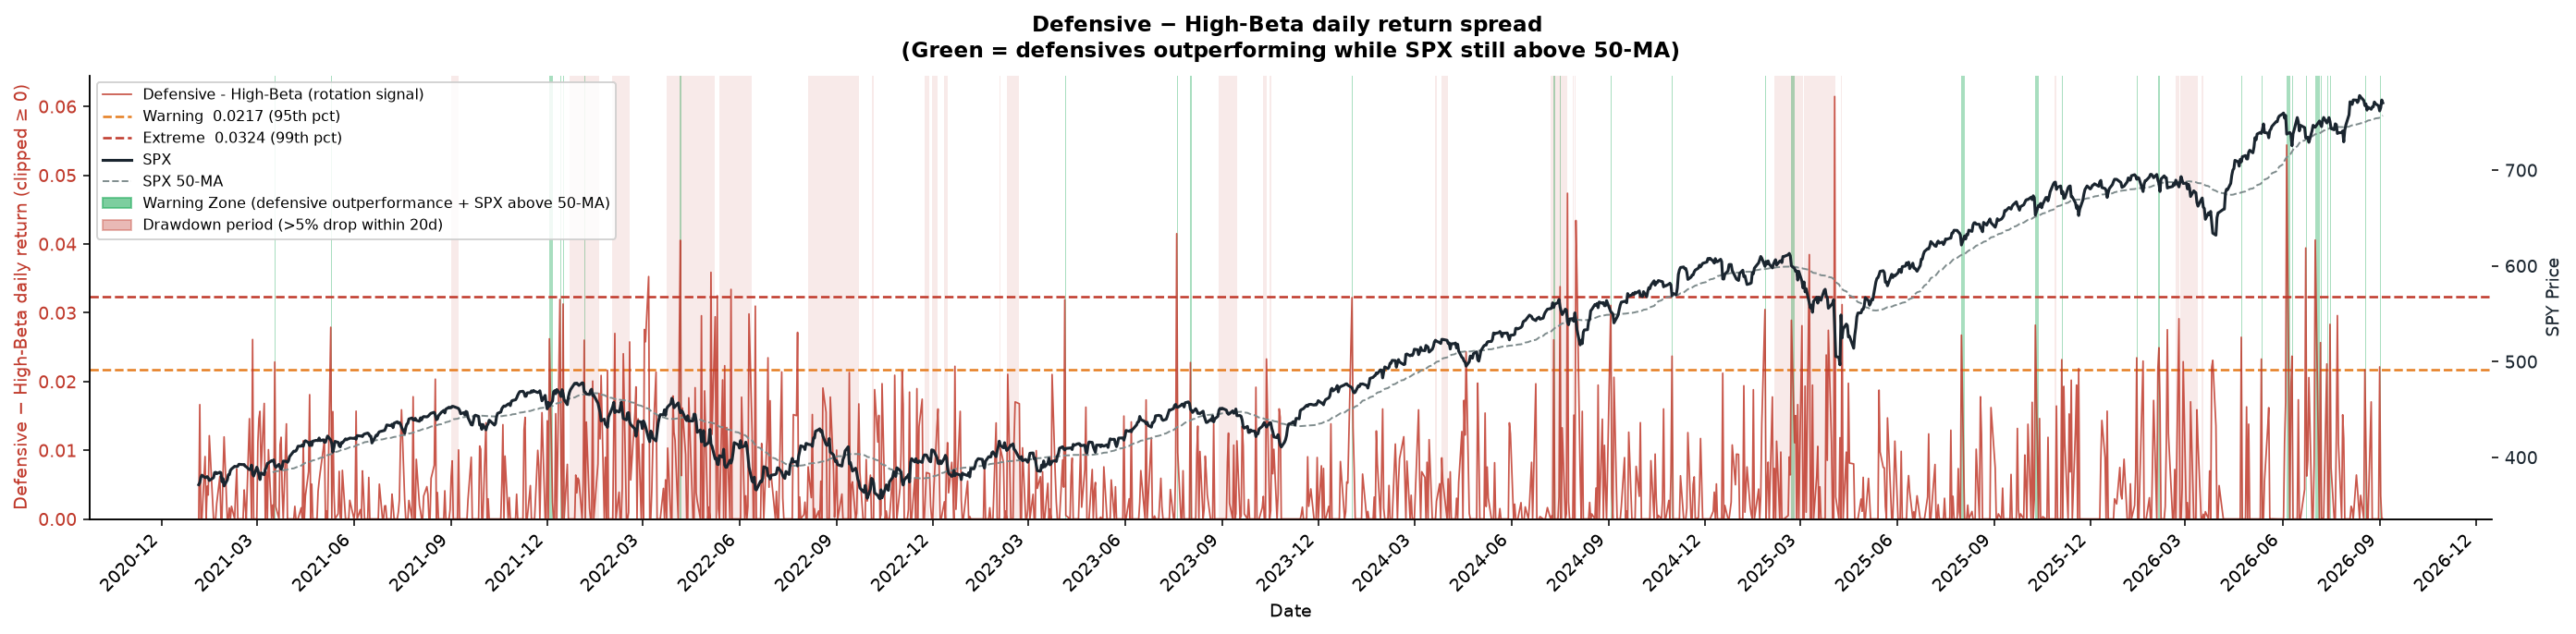

Range: 0.0000 - 0.0614
Warning (95th pct):  0.0217
Extreme (99th pct): 0.0324
Warning-zone days: 35 / 1,424


In [197]:
# Alt-A: 1-day return spread signal
#
# signal(t) = max(mean_return(XLP,XLV,XLU) - mean_return(XLK,XLY), 0)

DEF_TICKERS = ['XLP', 'XLV', 'XLU']
HB_TICKERS  = ['XLK', 'XLY']

daily_def_A = prices[DEF_TICKERS].pct_change().mean(axis=1)
daily_hb_A  = prices[HB_TICKERS ].pct_change().mean(axis=1)

sig_A     = (daily_def_A - daily_hb_A).clip(lower=0).dropna()
warn_A    = np.percentile(sig_A, WARN_PCT)
extreme_A = np.percentile(sig_A, EXTREME_PCT)

spx_A    = prices[BENCHMARK].reindex(sig_A.index)
spx_ma_A = prices[BENCHMARK].rolling(MA_WINDOW).mean().reindex(sig_A.index)
wzone_A  = (sig_A > warn_A) & (spx_A > spx_ma_A)

try:
    dd_A   = is_pre_dd_.reindex(sig_A.index).fillna(False)
    has_dd = True
except NameError:
    has_dd = False

fig, ax1 = plt.subplots(figsize=(20, 5))

ax1.plot(sig_A.index, sig_A.values, color='#c0392b', lw=0.9, alpha=0.85,
         label='Defensive - High-Beta (rotation signal)', zorder=3)
ax1.axhline(warn_A,    color='#e67e22', linestyle='--', lw=1.3,
            label=f'Warning  {warn_A:.4f} ({WARN_PCT}th pct)')
ax1.axhline(extreme_A, color='#c0392b', linestyle='--', lw=1.3,
            label=f'Extreme  {extreme_A:.4f} ({EXTREME_PCT}th pct)')
ax1.set_ylabel('Defensive − High-Beta daily return (clipped ≥ 0)', color='#c0392b', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(spx_A.index,    spx_A.values,    color='#1a252f', lw=1.6, label='SPX', zorder=4)
ax2.plot(spx_ma_A.index, spx_ma_A.values, color='#7f8c8d', lw=1.0, linestyle='--',
         label=f'SPX {MA_WINDOW}-MA', zorder=3)
ax2.set_ylabel('SPY Price', color='#1a252f', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#1a252f')

shade_regions(ax1, wzone_A, '#27ae60', 0.40)
if has_dd:
    shade_regions(ax1, dd_A, '#c0392b', 0.10)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
green_p = Patch(color='#27ae60', alpha=0.6,
                label='Warning Zone (defensive outperformance + SPX above 50-MA)')
all_handles = lines1 + lines2 + [green_p]
all_labels  = labs1  + labs2  + [green_p.get_label()]
if has_dd:
    red_p = Patch(color='#c0392b', alpha=0.35,
                  label=f'Drawdown period (>{abs(DD_THRESH):.0%} drop within {FWD_WINDOW}d)')
    all_handles.append(red_p); all_labels.append(red_p.get_label())
ax2.legend(all_handles, all_labels, loc='upper left', fontsize=8, framealpha=0.85)

ax1.set_xlabel('Date', fontsize=10)
ax1.set_title(
    'Defensive − High-Beta daily return spread \n'
    '(Green = defensives outperforming while SPX still above 50-MA)',
    fontweight='bold', fontsize=12, pad=10
)
plt.tight_layout()
plt.show()

print(f'Range: {sig_A.min():.4f} - {sig_A.max():.4f}')
print(f'Warning ({WARN_PCT}th pct):  {warn_A:.4f}')
print(f'Extreme ({EXTREME_PCT}th pct): {extreme_A:.4f}')
print(f'Warning-zone days: {wzone_A.sum():,} / {len(sig_A):,}')

In [198]:
# For each day t, label it pre-drawdown if SPY falls more than DD_THRESH below
# today's price at any point in the next FWD_WINDOW trading days:
#
#   fwd_max_dd(t) = min(SPY[t+1 .. t+20]) / SPY[t] - 1
#   is_pre_dd(t)  = fwd_max_dd(t) < -5%

spx = prices[BENCHMARK]

spx_arr     = spx.values
n           = len(spx_arr)
fwd_min_arr = np.full(n, np.nan)

for i in range(n - FWD_WINDOW):
    fwd_min_arr[i] = spx_arr[i + 1 : i + FWD_WINDOW + 1].min()

fwd_min    = pd.Series(fwd_min_arr, index=spx.index)
fwd_max_dd = (fwd_min - spx) / spx
is_pre_dd  = fwd_max_dd < DD_THRESH

spx_50ma = spx.rolling(MA_WINDOW).mean()

# Align everything to the signal index
idx        = signal.index
spx_       = spx.reindex(idx)
spx_50ma_  = spx_50ma.reindex(idx)
spread_    = spread.reindex(idx)
is_pre_dd_ = is_pre_dd.reindex(idx).fillna(False)

# Warning zone: rotation signal above threshold AND SPY still above 50-MA
warn_zone = (signal > warn_thresh) & (spx_ > spx_50ma_)


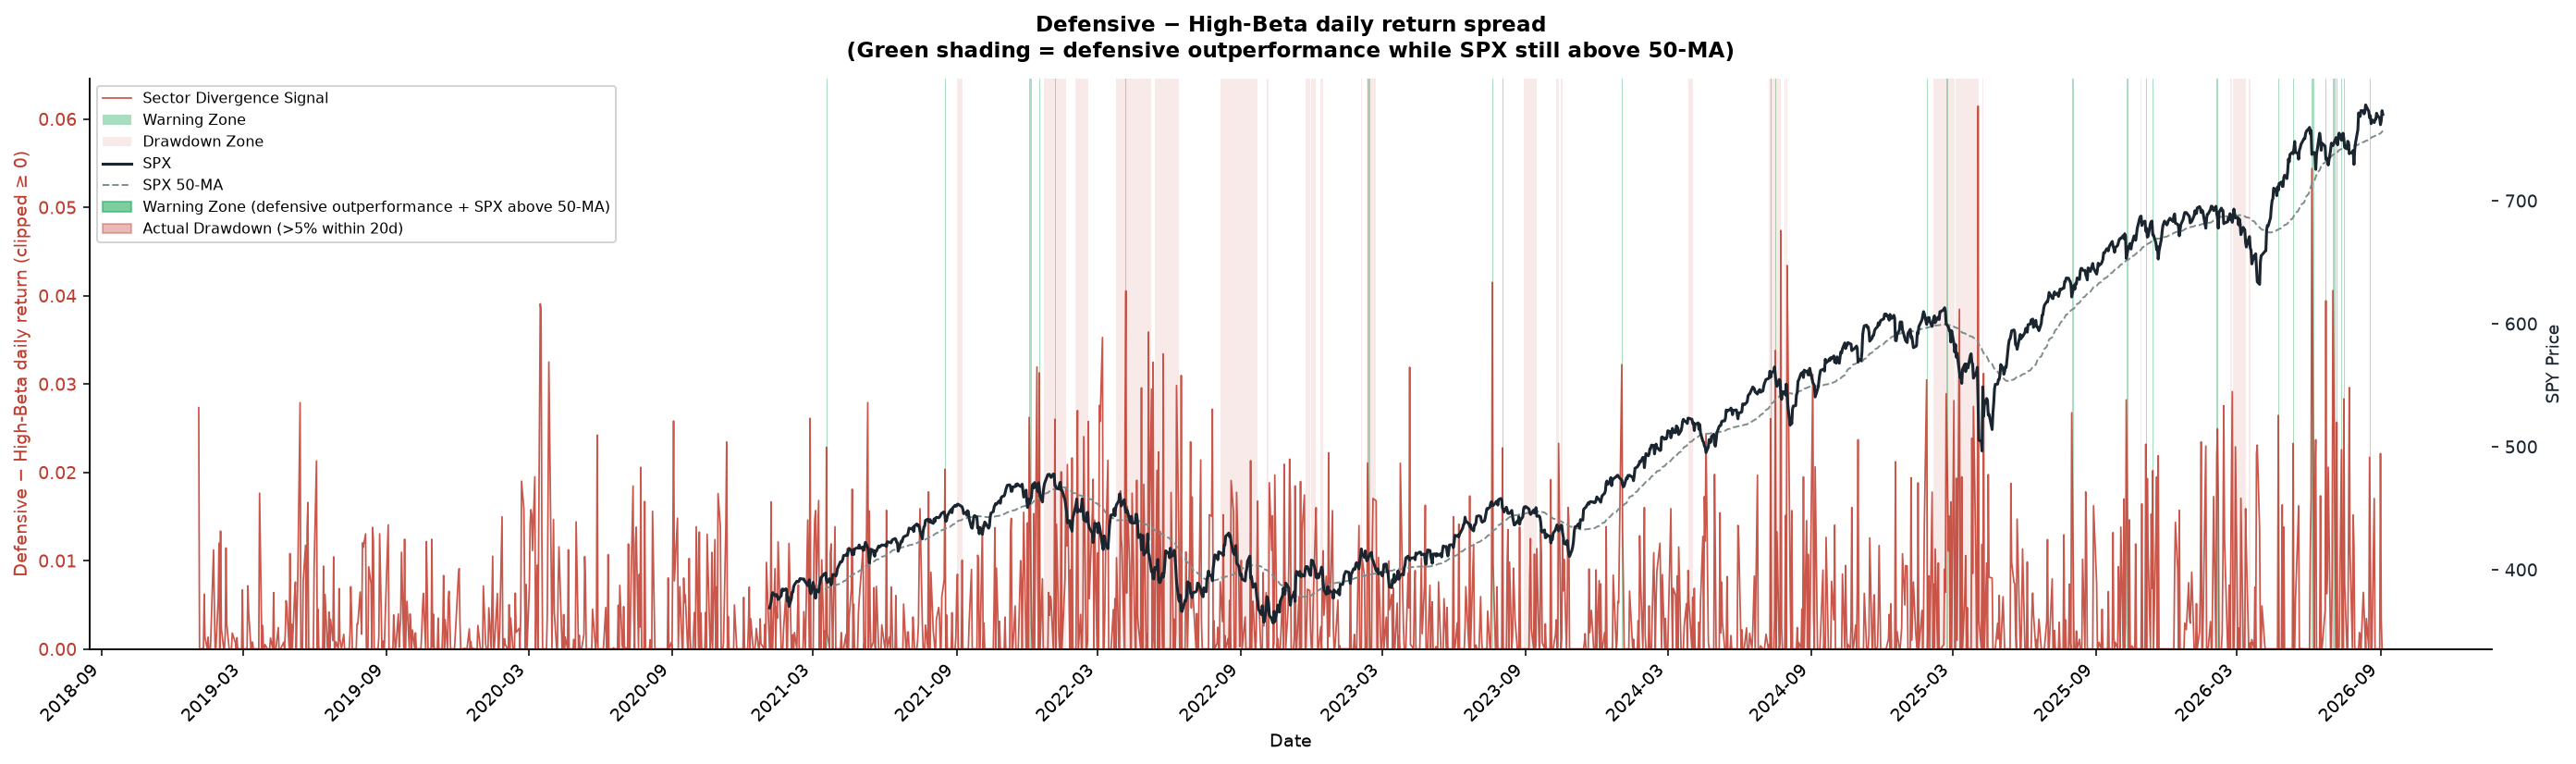

Chart saved → sector_rotation_full.png


In [199]:
def shade_regions(ax, mask, color, alpha, label=None):
    """Efficiently shade contiguous True blocks in a boolean Series."""
    in_region = False
    start = None
    added = False
    for date, val in mask.items():
        if val and not in_region:
            start, in_region = date, True
        elif not val and in_region:
            ax.axvspan(start, date, alpha=alpha, color=color,
                       linewidth=0, label=None if added else label)
            added, in_region = True, False
    if in_region:
        ax.axvspan(start, mask.index[-1], alpha=alpha, color=color, linewidth=0)


fig, ax1 = plt.subplots(figsize=(20, 6))

# ── Left axis: turbulence signal
ax1.plot(signal.index, signal.values, color='#c0392b', linewidth=0.9,
         alpha=0.85, label='Sector Divergence Signal', zorder=3)
ax1.set_ylabel('Defensive − High-Beta daily return (clipped ≥ 0)', color='#c0392b', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#c0392b')
ax1.set_ylim(bottom=0)

# ── Right axis: SPY
ax2 = ax1.twinx()
ax2.plot(spx_.index, spx_.values, color='#1a252f', linewidth=1.6,
         label='SPX', zorder=4)
ax2.plot(spx_50ma_.index, spx_50ma_.values, color='#7f8c8d', linewidth=1.0,
         linestyle='--', label='SPX 50-MA', zorder=3)
ax2.set_ylabel('SPY Price', color='#1a252f', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#1a252f')

# ── Shading
shade_regions(ax1, warn_zone,  color='#27ae60', alpha=0.40, label='Warning Zone')
shade_regions(ax1, is_pre_dd_, color='#c0392b', alpha=0.10, label='Drawdown Zone')

# ── Date formatting
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Legend
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
green_p = Patch(color='#27ae60', alpha=0.6,  label='Warning Zone (defensive outperformance + SPX above 50-MA)')
red_p   = Patch(color='#c0392b', alpha=0.35, label=f'Actual Drawdown (>{abs(DD_THRESH):.0%} within {FWD_WINDOW}d)')
ax2.legend(lines1 + lines2 + [green_p, red_p],
           labs1  + labs2  + [green_p.get_label(), red_p.get_label()],
           loc='upper left', fontsize=8, framealpha=0.85)

ax1.set_xlabel('Date', fontsize=10)
ax1.set_title(
    'Defensive − High-Beta daily return spread\n'
    '(Green shading = defensive outperformance while SPX still above 50-MA)',
    fontsize=12, fontweight='bold', pad=12
)

plt.tight_layout()
plt.savefig('sector_rotation_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → sector_rotation_full.png')

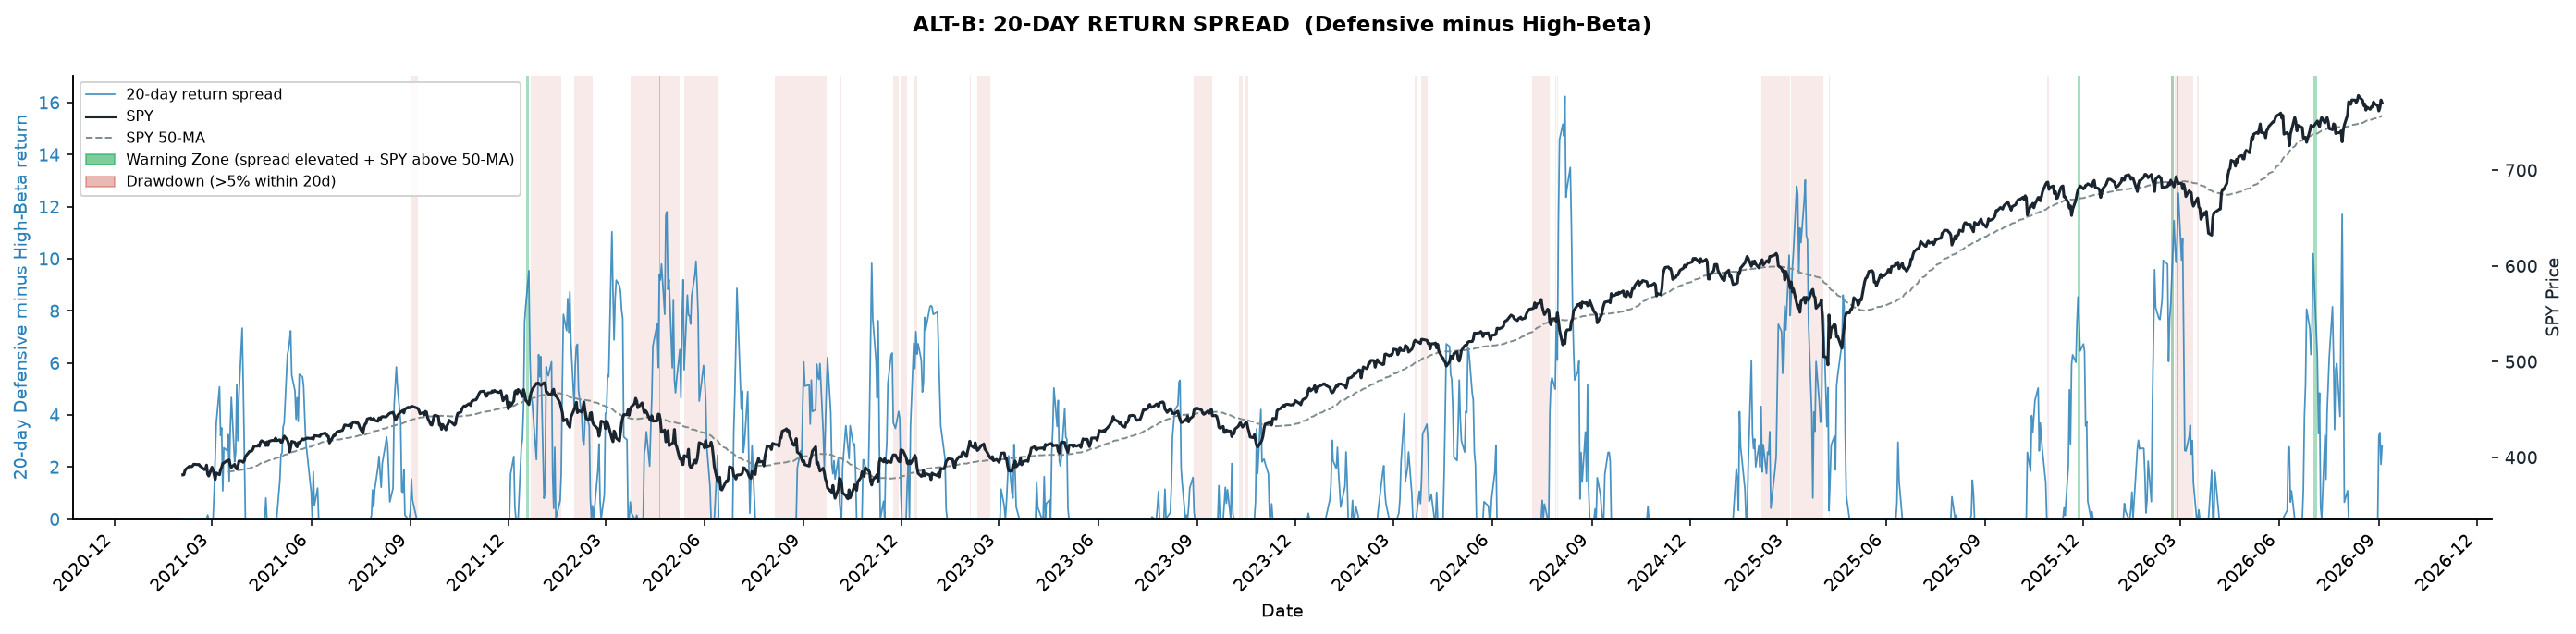

In [200]:
#  Alt-B: 20-day return spread signal
#
# D_t = mean_20day_return(Defensive) - mean_20day_return(HighBeta), clipped >= 0
#
# Uses MOM_WINDOW (20 trading days) cumulative returns instead of 1-day returns.

DEF_B = ['XLP', 'XLV', 'XLU']
HB_B  = ['XLK', 'XLY']

ret20_def = prices[DEF_B].pct_change(MOM_WINDOW).mean(axis=1)
ret20_hb  = prices[HB_B].pct_change(MOM_WINDOW).mean(axis=1)

sig_B     = ((ret20_def - ret20_hb).clip(lower=0) * 100).dropna()  # in percentage points
warn_B    = np.percentile(sig_B, WARN_PCT)
extreme_B = np.percentile(sig_B, EXTREME_PCT)

spx_B    = prices[BENCHMARK].reindex(sig_B.index)
spx_ma_B = prices[BENCHMARK].rolling(MA_WINDOW).mean().reindex(sig_B.index)
wzone_B  = (sig_B > warn_B) & (spx_B > spx_ma_B)
dd_B     = is_pre_dd_.reindex(sig_B.index).fillna(False)

# Event-level recall / precision (symmetric 40-day window)
sig_fire_B  = sig_B > warn_B
dd_int_B    = dd_B.astype(int)
dd_events_B = dd_B.index[(dd_int_B == 1) & (dd_int_B.shift(1, fill_value=0) == 0)].tolist()
sf_int_B    = sig_fire_B.astype(int)
eps_B       = sig_B.index[(sf_int_B == 1) & (sf_int_B.shift(1, fill_value=0) == 0)].tolist()

warned_B  = sum(1 for ev in dd_events_B if sig_fire_B.loc[
    (sig_fire_B.index >= ev - pd.Timedelta(days=40)) & (sig_fire_B.index < ev)].any())
correct_B = sum(1 for ep in eps_B if any(
    ep <= ev <= ep + pd.Timedelta(days=40) for ev in dd_events_B))
recall_B  = warned_B  / len(dd_events_B) if dd_events_B else 0
prec_B    = correct_B / len(eps_B)       if eps_B       else 0
f1_B      = 2*prec_B*recall_B / (prec_B+recall_B) if (prec_B+recall_B) else 0

# Chart
fig, ax1 = plt.subplots(figsize=(20, 5))
ax1.plot(sig_B.index, sig_B.values, color='#2980b9', lw=0.9, alpha=0.85,
         label='20-day return spread', zorder=3)
ax1.set_ylabel('20-day Defensive minus High-Beta return',
               color='#2980b9', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#2980b9')
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(spx_B.index,    spx_B.values,    color='#1a252f', lw=1.6, label='SPY', zorder=4)
ax2.plot(spx_ma_B.index, spx_ma_B.values, color='#7f8c8d', lw=1.0, linestyle='--',
         label=f'SPY {MA_WINDOW}-MA', zorder=3)
ax2.set_ylabel('SPY Price', color='#1a252f', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#1a252f')

shade_regions(ax1, wzone_B, '#27ae60', 0.40)
shade_regions(ax1, dd_B,    '#c0392b', 0.10)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
green_p = Patch(color='#27ae60', alpha=0.6, label='Warning Zone (spread elevated + SPY above 50-MA)')
red_p   = Patch(color='#c0392b', alpha=0.35,
                label=f'Drawdown (>{abs(DD_THRESH):.0%} within {FWD_WINDOW}d)')
ax2.legend(lines1 + lines2 + [green_p, red_p],
           labs1  + labs2  + [green_p.get_label(), red_p.get_label()],
           loc='upper left', fontsize=8, framealpha=0.85)

ax1.set_xlabel('Date', fontsize=10)
ax1.set_title(
    'ALT-B: 20-DAY RETURN SPREAD  (Defensive minus High-Beta)\n',
    fontweight='bold', fontsize=12, pad=10
)
plt.tight_layout()
plt.savefig('alt_b_20day_spread.png', dpi=150, bbox_inches='tight')
plt.show()


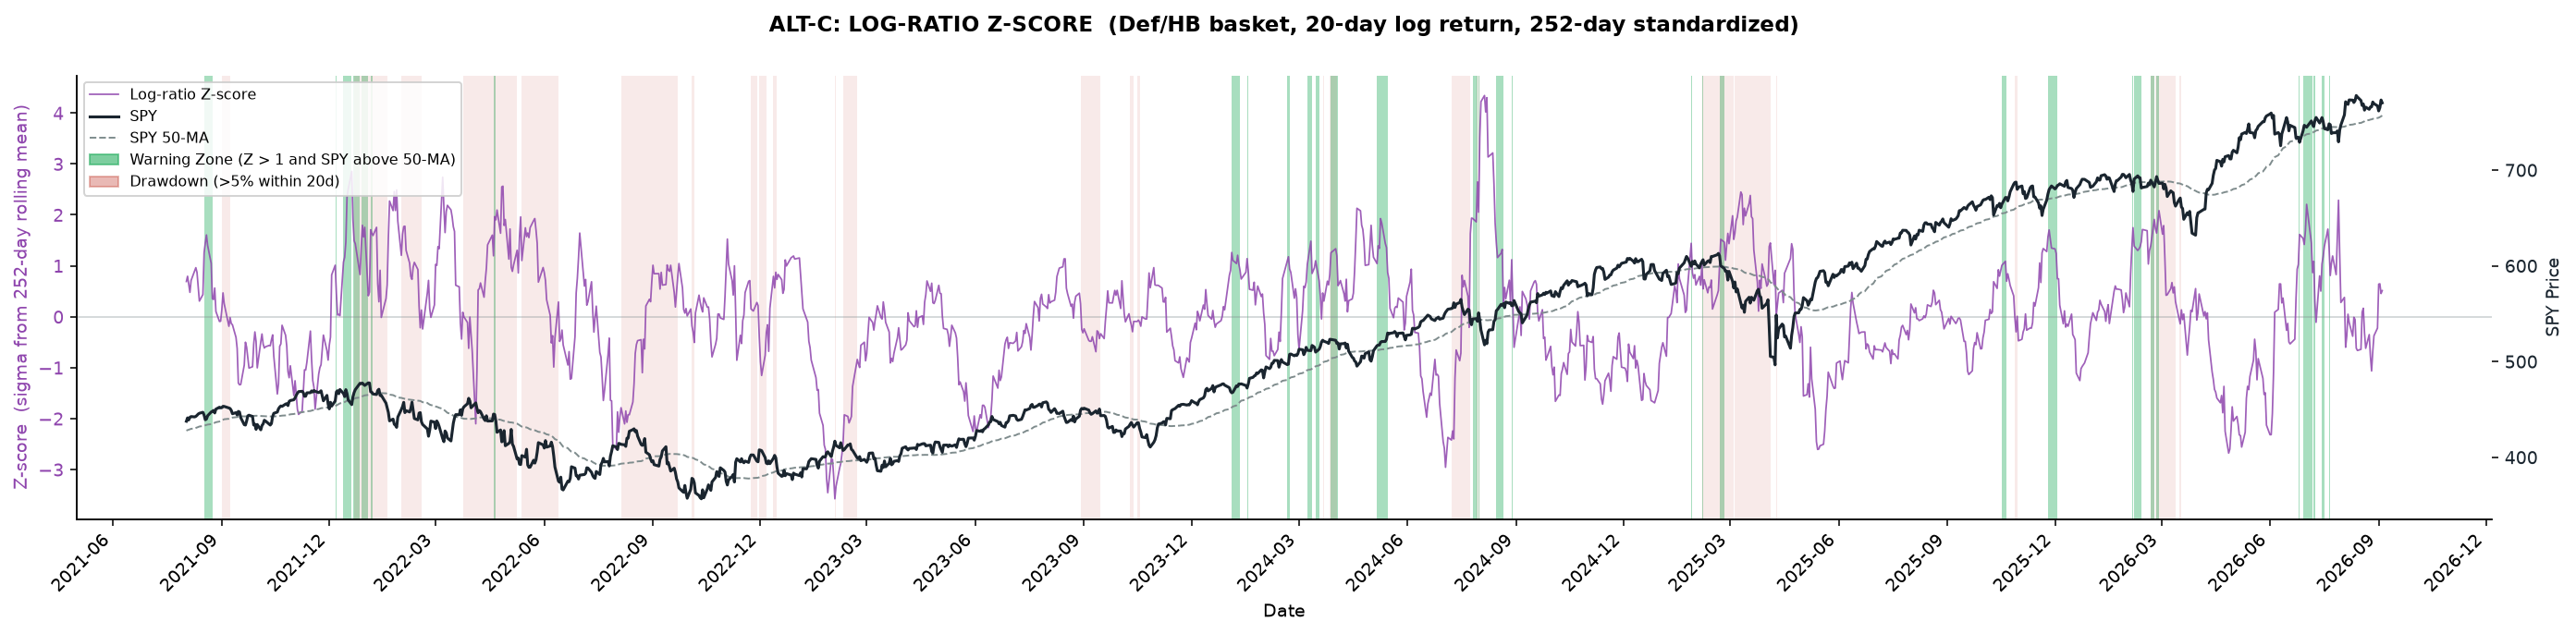

Z-score range:  -3.57  to  4.34
Warning zone: Z > 1.0   Extreme: Z > 2.0
Warning-zone days: 80 / 1,280  (6.2%)
Crash events: 27   Episodes fired: 45
Event recall:  89%  (24/27)   Precision: 67%  (30/45)   F1: 0.762


In [201]:
#  Alt-C: Log-ratio Z-score signal 
#
# Step 1: Index each ETF to 100 at start (equal-weighting within basket)
# Step 2: Basket price = mean of indexed prices
# Step 3: Ratio = defensive_basket / high_beta_basket
# Step 4: D_t = log(Ratio_t / Ratio_{t-20})  - 20-day log return of ratio
# Step 5: Z_t = (D_t - rolling_mean(D, 252)) / rolling_std(D, 252)


DEF_C = ['XLP', 'XLV', 'XLU']
HB_C  = ['XLK', 'XLY']

# Index each ETF to 100 at first available date so no single ETF dominates
def_idx = prices[DEF_C].div(prices[DEF_C].iloc[0]) * 100
hb_idx  = prices[HB_C].div(prices[HB_C].iloc[0]) * 100

def_basket_C = def_idx.mean(axis=1)
hb_basket_C  = hb_idx.mean(axis=1)

ratio_C = def_basket_C / hb_basket_C
D_C     = np.log(ratio_C / ratio_C.shift(MOM_WINDOW))  # 20-day log return of ratio

Z_C = (
    (D_C - D_C.rolling(ZSCORE_WINDOW, min_periods=126).mean())
    / D_C.rolling(ZSCORE_WINDOW, min_periods=126).std()
).dropna()

warn_C    = 1.0   # 1 sigma above rolling mean = unusually defensive
extreme_C = 2.0   # 2 sigma

spx_C    = prices[BENCHMARK].reindex(Z_C.index)
spx_ma_C = prices[BENCHMARK].rolling(MA_WINDOW).mean().reindex(Z_C.index)
wzone_C  = (Z_C > warn_C) & (spx_C > spx_ma_C)
dd_C     = is_pre_dd_.reindex(Z_C.index).fillna(False)

# Event-level recall / precision (symmetric 40-day window)
sig_fire_C  = Z_C > warn_C
dd_int_C    = dd_C.astype(int)
dd_events_C = dd_C.index[(dd_int_C == 1) & (dd_int_C.shift(1, fill_value=0) == 0)].tolist()
sf_int_C    = sig_fire_C.astype(int)
eps_C       = Z_C.index[(sf_int_C == 1) & (sf_int_C.shift(1, fill_value=0) == 0)].tolist()

warned_C  = sum(1 for ev in dd_events_C if sig_fire_C.loc[
    (sig_fire_C.index >= ev - pd.Timedelta(days=40)) & (sig_fire_C.index < ev)].any())
correct_C = sum(1 for ep in eps_C if any(
    ep <= ev <= ep + pd.Timedelta(days=40) for ev in dd_events_C))
recall_C  = warned_C  / len(dd_events_C) if dd_events_C else 0
prec_C    = correct_C / len(eps_C)       if eps_C       else 0
f1_C      = 2*prec_C*recall_C / (prec_C+recall_C) if (prec_C+recall_C) else 0

# Chart
fig, ax1 = plt.subplots(figsize=(20, 5))
ax1.plot(Z_C.index, Z_C.values, color='#8e44ad', lw=0.9, alpha=0.85,
         label='Log-ratio Z-score', zorder=3)
ax1.axhline(0,          color='#7f8c8d', linestyle='-',  lw=0.8, alpha=0.4)
ax1.set_ylabel('Z-score  (sigma from 252-day rolling mean)', color='#8e44ad', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#8e44ad')

ax2 = ax1.twinx()
ax2.plot(spx_C.index,    spx_C.values,    color='#1a252f', lw=1.6, label='SPY', zorder=4)
ax2.plot(spx_ma_C.index, spx_ma_C.values, color='#7f8c8d', lw=1.0, linestyle='--',
         label=f'SPY {MA_WINDOW}-MA', zorder=3)
ax2.set_ylabel('SPY Price', color='#1a252f', fontsize=10)
ax2.tick_params(axis='y', labelcolor='#1a252f')

shade_regions(ax1, wzone_C, '#27ae60', 0.40)
shade_regions(ax1, dd_C,    '#c0392b', 0.10)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
green_p = Patch(color='#27ae60', alpha=0.6,
                label='Warning Zone (Z > 1 and SPY above 50-MA)')
red_p   = Patch(color='#c0392b', alpha=0.35,
                label=f'Drawdown (>{abs(DD_THRESH):.0%} within {FWD_WINDOW}d)')
ax2.legend(lines1 + lines2 + [green_p, red_p],
           labs1  + labs2  + [green_p.get_label(), red_p.get_label()],
           loc='upper left', fontsize=8, framealpha=0.85)

ax1.set_xlabel('Date', fontsize=10)
ax1.set_title(
    'ALT-C: LOG-RATIO Z-SCORE  (Def/HB basket, 20-day log return, 252-day standardized)\n',
    fontweight='bold', fontsize=12, pad=10
)
plt.tight_layout()
plt.savefig('alt_c_logratio_zscore.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Z-score range:  {Z_C.min():.2f}  to  {Z_C.max():.2f}')
print(f'Warning zone: Z > {warn_C}   Extreme: Z > {extreme_C}')
print(f'Warning-zone days: {wzone_C.sum():,} / {len(Z_C):,}  ({wzone_C.mean():.1%})')
print(f'Crash events: {len(dd_events_C)}   Episodes fired: {len(eps_C)}')
print(f'Event recall:  {recall_C:.0%}  ({warned_C}/{len(dd_events_C)})   '
      f'Precision: {prec_C:.0%}  ({correct_C}/{len(eps_C)})   F1: {f1_C:.3f}')


In [202]:
# Evaluates all three signals using the same event-level methodology, comparin them:
# - 40-day window for recall and precision

PRECEDE = 40  # calendar days

def event_metrics(sig, warn_t, dd_labels, spx_ser, spx_ma_ser):
    sig_fire  = sig > warn_t
    wzone     = sig_fire & (spx_ser.reindex(sig.index) > spx_ma_ser.reindex(sig.index))
    dd        = dd_labels.reindex(sig.index).fillna(False)

    dd_int    = dd.astype(int)
    dd_events = dd.index[(dd_int == 1) & (dd_int.shift(1, fill_value=0) == 0)].tolist()

    sf_int    = sig_fire.astype(int)
    episodes  = sig.index[(sf_int == 1) & (sf_int.shift(1, fill_value=0) == 0)].tolist()

    warned  = sum(1 for ev in dd_events if sig_fire.loc[
        (sig_fire.index >= ev - pd.Timedelta(days=PRECEDE)) &
        (sig_fire.index <  ev)].any())
    correct = sum(1 for ep in episodes if any(
        ep <= ev <= ep + pd.Timedelta(days=PRECEDE) for ev in dd_events))

    recall = warned  / len(dd_events) if dd_events else 0
    prec   = correct / len(episodes)  if episodes  else 0
    f1     = 2*prec*recall / (prec+recall) if (prec+recall) else 0

    return dict(
        events   = len(dd_events),
        episodes = len(episodes),
        warned   = warned,
        correct  = correct,
        recall   = recall,
        prec     = prec,
        f1       = f1,
        wzone_pct = wzone.mean(),
    )

# ── Run for all three signals ─────────────────────────────────────────────────
m_A = event_metrics(signal,  warn_thresh, is_pre_dd_, spx_, spx_50ma_)
m_B = event_metrics(sig_B,   warn_B,      is_pre_dd_, spx_, spx_50ma_)
m_C = event_metrics(Z_C,     warn_C,      is_pre_dd_, spx_, spx_50ma_)

# ── Print ─────────────────────────────────────────────────────────────────────
hdr = f"{'Metric':<32} {'1-day spread':>14} {'20-day spread':>14} {'Log-ratio Z':>14}"
sep = '-' * len(hdr)
print(sep)
print(hdr)
print(sep)

rows = [
    ('Events warned (recall)',
     f"{m_A['warned']} ({m_A['recall']:.0%})",
     f"{m_B['warned']} ({m_B['recall']:.0%})",
     f"{m_C['warned']} ({m_C['recall']:.0%})"),
    ('Episodes -> crash (precision)',
     f"{m_A['correct']} ({m_A['prec']:.0%})",
     f"{m_B['correct']} ({m_B['prec']:.0%})",
     f"{m_C['correct']} ({m_C['prec']:.0%})"),
    ('Event F1',
     f"{m_A['f1']:.3f}",   f"{m_B['f1']:.3f}",   f"{m_C['f1']:.3f}"),
]

for label, a, b, c in rows:
    print(f"{label:<32} {str(a):>14} {str(b):>14} {str(c):>14}")

print(sep)


-----------------------------------------------------------------------------
Metric                             1-day spread  20-day spread    Log-ratio Z
-----------------------------------------------------------------------------
Events warned (recall)                 21 (78%)       14 (52%)       24 (89%)
Episodes -> crash (precision)          41 (46%)       18 (69%)       30 (67%)
Event F1                                  0.575          0.593          0.762
-----------------------------------------------------------------------------


Total drawdown events found:         27
Events with a preceding signal:      21 (78%)
Median lead time (days):             35
Mean lead time (days):               28
Min / Max lead time:                 3 / 40 days


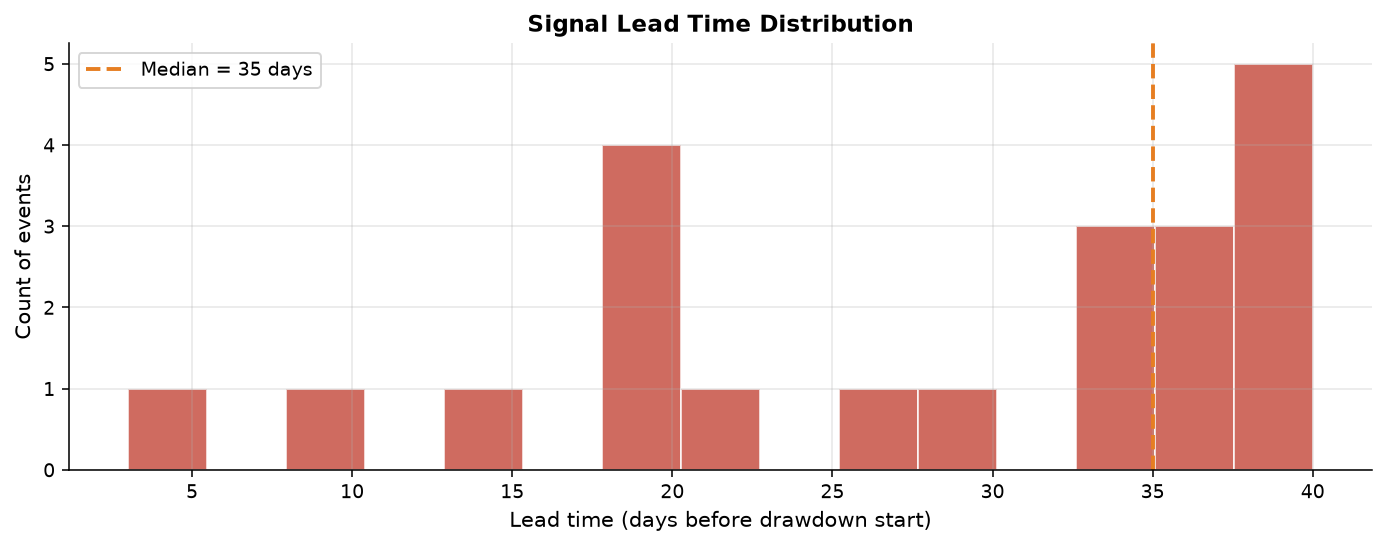

In [203]:
# For each drawdown event, how many days before it did the signal first trigger?

# Find drawdown event starts (first day of each contiguous pre-drawdown block)
dd_series = is_pre_dd_.astype(int)
dd_starts = dd_series[(dd_series == 1) & (dd_series.shift(1) == 0)].index

lead_times = []
LOOKBACK_DAYS = 40  # how far back to search for a signal trigger

for dd_start in dd_starts:
    window_start = dd_start - pd.Timedelta(days=LOOKBACK_DAYS)
    window = signal[window_start:dd_start]
    triggered = window[window > warn_thresh]
    if len(triggered) > 0:
        first_trigger = triggered.index[0]
        lead = (dd_start - first_trigger).days
        lead_times.append(lead)

lead_arr = np.array(lead_times)

print(f"Total drawdown events found:         {len(dd_starts)}")
print(f"Events with a preceding signal:      {len(lead_arr)} ({len(lead_arr)/len(dd_starts):.0%})")
print(f"Median lead time (days):             {np.median(lead_arr):.0f}")
print(f"Mean lead time (days):               {np.mean(lead_arr):.0f}")
print(f"Min / Max lead time:                 {lead_arr.min()} / {lead_arr.max()} days")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lead_arr, bins=15, color='#c0392b', alpha=0.75, edgecolor='white')
ax.axvline(np.median(lead_arr), color='#e67e22', linestyle='--', linewidth=2,
           label=f'Median = {np.median(lead_arr):.0f} days')
ax.set_xlabel('Lead time (days before drawdown start)', fontsize=11)
ax.set_ylabel('Count of events', fontsize=11)
ax.set_title('Signal Lead Time Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lead_time.png', dpi=150, bbox_inches='tight')
plt.show()